# Fraud Detection: Exploratory Data Analysis I
## Number of Transactions per Transaction Amount by Class and Type


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
data = pd.read_csv('/content/CreditCardFraud_Dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TransactionID    10000 non-null  object
 1   Time             10000 non-null  int64 
 2   Amount           10000 non-null  int64 
 3   MerchantID       10000 non-null  object
 4   TransactionType  10000 non-null  object
 5   Class            10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


# Number of Transactions per Transaction Amount by Class

In [27]:
# number of transactions per transaction amount by class
transaction_count_amount = data.pivot_table(
    index="Amount",
    columns="Class",
    values="TransactionID",
    aggfunc="count",
    fill_value=0
)

# total number of transactions and fraud rate
transaction_count_amount['Total'] = transaction_count_amount['Fraudulent'] + transaction_count_amount['Normal']
transaction_count_amount['Fraud_Rate'] = transaction_count_amount['Fraudulent'] / transaction_count_amount['Total']

transaction_count_amount.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1187 entries, 1 to 4995
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fraudulent  1187 non-null   int64  
 1   Normal      1187 non-null   int64  
 2   Total       1187 non-null   int64  
 3   Fraud_Rate  1187 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 46.4 KB


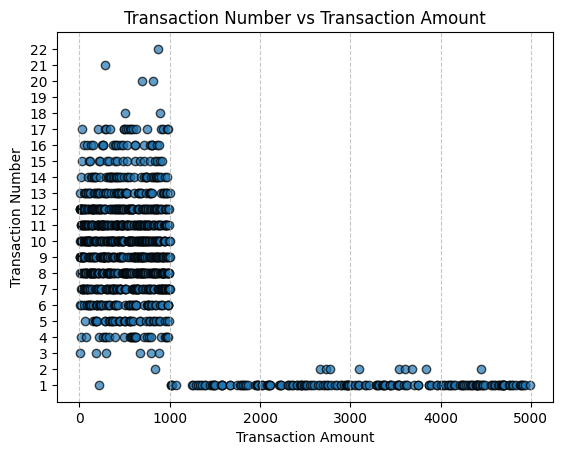

In [28]:
# scatter plot: transaction number vs transaction amount
plt.scatter(
    transaction_count_amount.index,
    transaction_count_amount['Total'],
    alpha=0.7,
    edgecolors='k'
    )

plt.title("Transaction Number vs Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Number")
plt.yticks(range(1, transaction_count_amount['Total'].max() + 1))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

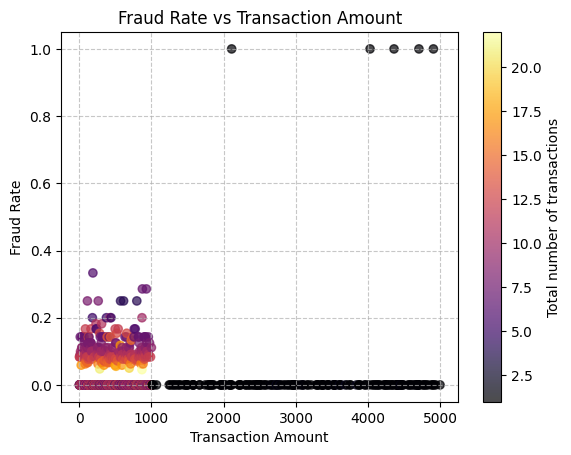

In [29]:
# scatter plot: fraud rate vs transaction amount
plt.scatter(
    transaction_count_amount.index,
    transaction_count_amount['Fraud_Rate'],
    c=transaction_count_amount['Total'],
    # cmap='viridis',
    # cmap='plasma',
    cmap='inferno',
    # cmap='magma',
    # cmap='cividis',
    alpha=0.7,
    )

plt.title("Fraud Rate vs Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.colorbar(label="Total number of transactions")
plt.show()

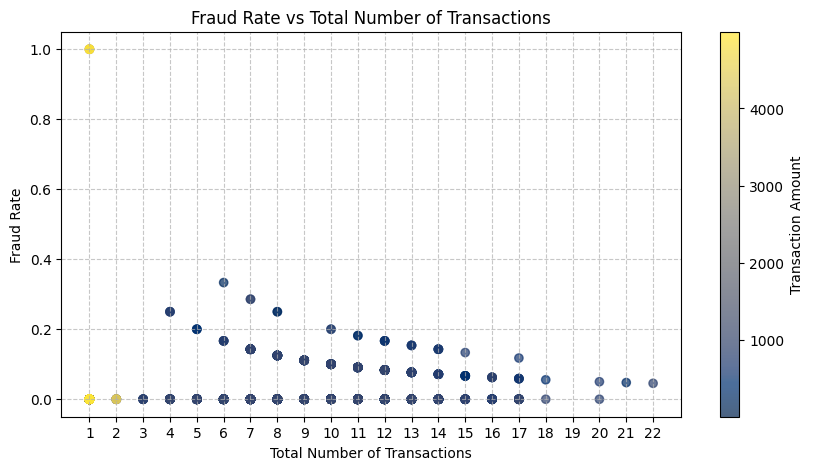

In [30]:
# scatter plot: fraud rate vs total number of transactions
plt.figure(figsize=(10,5))
plt.scatter(
    transaction_count_amount['Total'],
    transaction_count_amount['Fraud_Rate'],
    c=transaction_count_amount.index,
    cmap='cividis',
    alpha=0.7,
    )

plt.title("Fraud Rate vs Total Number of Transactions")
plt.xlabel("Total Number of Transactions")
plt.ylabel("Fraud Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xticks(range(1, transaction_count_amount['Total'].max() + 1))
plt.colorbar(label="Transaction Amount")
plt.show()

# Number of Transactions per Transaction Amount by Class and Type

In [31]:
# number of transactions per transaction amount by class and transaction type
transaction_count_amount_class_type = data.pivot_table(
    index="Amount",
    columns=["TransactionType","Class"],
    values="TransactionID",
    aggfunc="count",
    fill_value=0
)

# totals and fraud rates
transaction_count_amount_class_type[("Mobile","Total")] = transaction_count_amount_class_type[("Mobile","Fraudulent")] + transaction_count_amount_class_type[("Mobile","Normal")]
transaction_count_amount_class_type[("Online","Total")] = transaction_count_amount_class_type[("Online","Fraudulent")] + transaction_count_amount_class_type[("Online","Normal")]
transaction_count_amount_class_type[("Mobile","Fraud_Rate")] = transaction_count_amount_class_type[("Mobile","Fraudulent")] / transaction_count_amount_class_type[("Mobile","Total")]
transaction_count_amount_class_type[("Online","Fraud_Rate")] = transaction_count_amount_class_type[("Online","Fraudulent")] / transaction_count_amount_class_type[("Online","Total")]

print(transaction_count_amount_class_type.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1187 entries, 1 to 4995
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (In-Store, Normal)    1187 non-null   int64  
 1   (Mobile, Fraudulent)  1187 non-null   int64  
 2   (Mobile, Normal)      1187 non-null   int64  
 3   (Online, Fraudulent)  1187 non-null   int64  
 4   (Online, Normal)      1187 non-null   int64  
 5   (Mobile, Total)       1187 non-null   int64  
 6   (Online, Total)       1187 non-null   int64  
 7   (Mobile, Fraud_Rate)  1020 non-null   float64
 8   (Online, Fraud_Rate)  1030 non-null   float64
dtypes: float64(2), int64(7)
memory usage: 92.7 KB
None


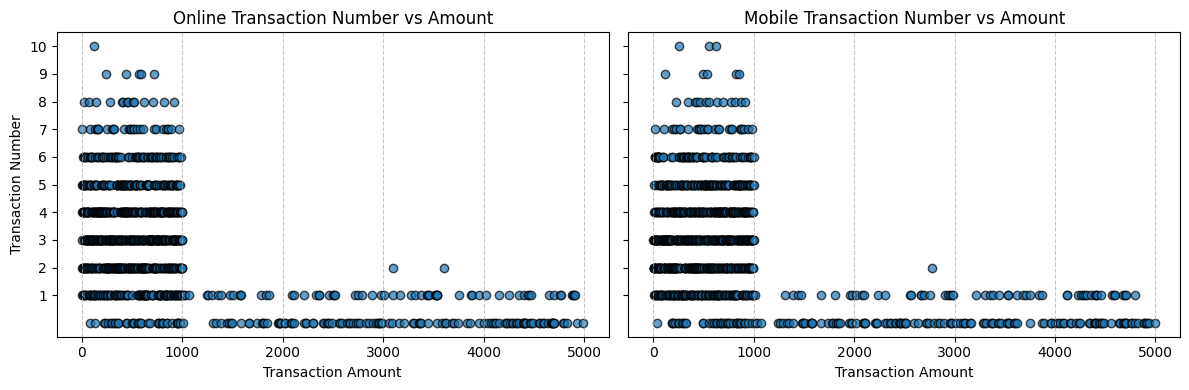

In [32]:
# scatter plot: online and mobile transaction number vs transaction amount
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharey=True)
types = ["Online", "Mobile"]
for i, t in enumerate(types):
    ax[i].scatter(
        transaction_count_amount_class_type.index,
        transaction_count_amount_class_type[(t, "Total")],
        alpha=0.7,
        edgecolors='k'
    )

    ax[i].set_title(f"{t} Transaction Number vs Amount")
    ax[i].set_xlabel("Transaction Amount")
    ax[i].grid(axis='x', linestyle='--', alpha=0.7)

ax[0].set_ylabel("Transaction Number")
max_y = transaction_count_amount_class_type[[("Online","Total"), ("Mobile","Total")]].max().max()
ax[0].set_yticks(range(1, max_y + 1))
plt.tight_layout()
plt.show()

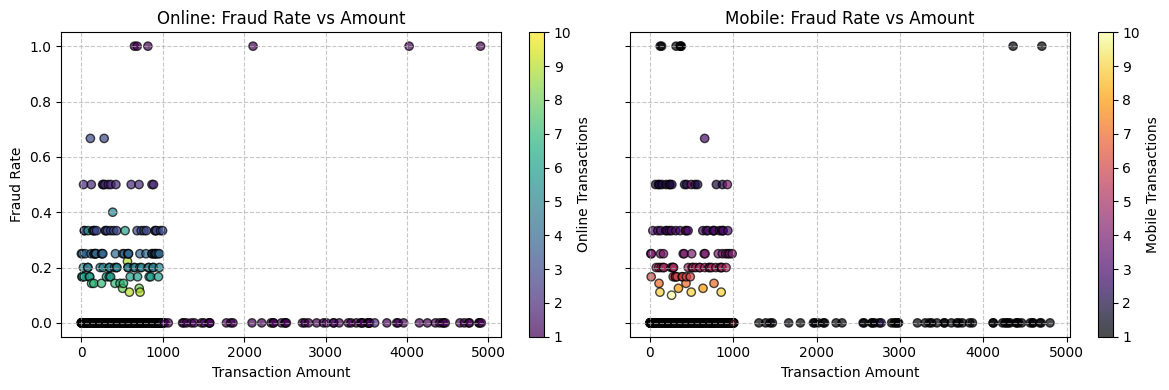

In [33]:
# scatter plot: fraud rate vs transaction amount
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharey=True)

types = ["Online", "Mobile"]
cmaps = ["viridis", "inferno"]

for i, t in enumerate(types):
    sc = ax[i].scatter(
        transaction_count_amount_class_type.index,
        transaction_count_amount_class_type[(t, "Fraud_Rate")],
        c=transaction_count_amount_class_type[(t, "Total")],
        cmap=cmaps[i],
        alpha=0.7,
        edgecolors='k'
    )

    ax[i].set_title(f"{t}: Fraud Rate vs Amount")
    ax[i].set_xlabel("Transaction Amount")
    ax[i].grid(axis='x', linestyle='--', alpha=0.7)
    ax[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.colorbar(sc, ax=ax[i], label=f"{t} Transactions")

ax[0].set_ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

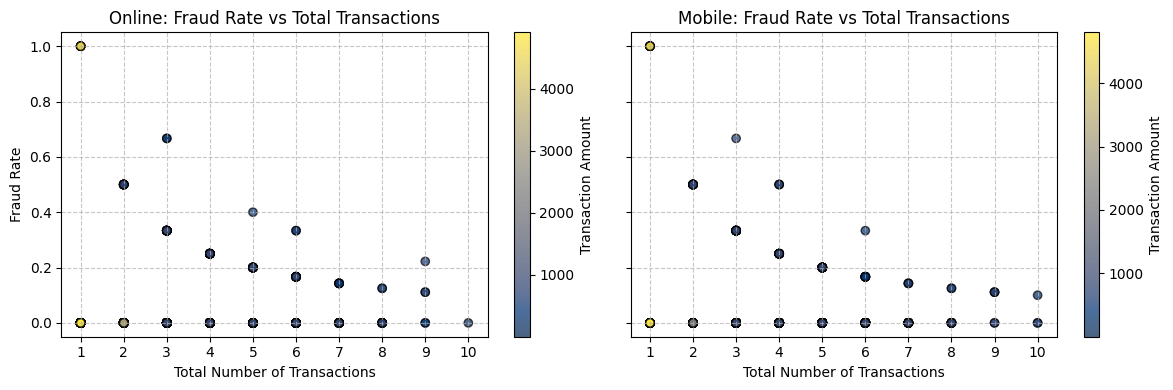

In [34]:
# scatter plot: online and mobile fraud rates vs total number of transactions
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharey=True)

types = ["Online", "Mobile"]
cmap = "cividis"

for i, t in enumerate(types):
    sc = ax[i].scatter(
        transaction_count_amount_class_type[(t, "Total")],
        transaction_count_amount_class_type[(t, "Fraud_Rate")],
        c=transaction_count_amount_class_type.index,
        cmap=cmap,
        alpha=0.7,
        edgecolors='k'
    )

    ax[i].set_title(f"{t}: Fraud Rate vs Total Transactions")
    ax[i].set_xlabel("Total Number of Transactions")
    ax[i].grid(axis='x', linestyle='--', alpha=0.7)
    ax[i].grid(axis='y', linestyle='--', alpha=0.7)

    ax[i].set_xticks(
        range(1, transaction_count_amount_class_type[(t, "Total")].max() + 1)
    )

    plt.colorbar(sc, ax=ax[i], label="Transaction Amount")

ax[0].set_ylabel("Fraud Rate")

plt.tight_layout()
plt.show()